# `1.11`

Используя любые источники информации, изучите метод обратной квадратичной
интерполяции (ОКИ) и вычислите его порядок сходимости (собрав всю теоретическую
информацию в отчет).

Решите с помощью этого метода уравнения
$$e^{-x} = x$$
и
$$x * sin(x) = 1$$

Для каждого уравнения постройте совмещенные диаграммы сходимости метода ОКИ,
секущих и Ньютона, подтверждающие полученное значения порядка сходимости

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# f1(x) = e^-x - x
def f1(x):
    return np.exp(-x) - x

# f1'(x) = -e ^ -x - 1
def df1(x):
    return -np.exp(-x) - 1

# f2(x) = x * sin(x) - 1
def f2(x):
    return x * np.sin(x) - 1

# f2'(x) = sin(x) + x * cos(x)
def df2(x):
    return np.sin(x) + x * np.cos(x)

## `Метод Ньютона`

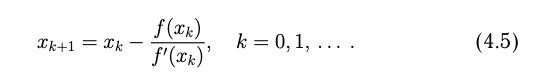

In [56]:
def newton_method(
    function, # функция
    derivative, # ее производная
    x0, # начальное приближение x0
    x_solution, # точное значение корня, чтобы считать ошибку
    eps=1e-12, # точность
    max_iterations=100 # max число итераций
):
    print("Ньютон")
    print(f"f: {function}")  
    iteration_errors = [abs(x0 - x_solution)] # для хранения погрешностей на каждой итерации
    
    current_x = x0
    
    for k in range(max_iterations):
        # вычисляем значения
        f_value = function(current_x) # f(x_k)
        df_value = derivative(current_x) # f'(x_k)
        
        # далее мы будем на нее делить, поэтому проверим
        if df_value == 0:
            print("ERROR: Производная равна нулю.")
            break
            
        # формула 4.5
        current_x = current_x - f_value / df_value
        print(f"it: {k + 1}, current_x: {current_x + 1}")
        # добавляем ошибку |x_k - x*|
        error = abs(current_x - x_solution)
        iteration_errors.append(error)
        
        # f(x_k) < eps
        if abs(f_value) < eps:
            break
    print()
    return iteration_errors

## `Метод секущих`

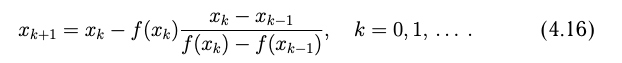

In [53]:
def secant_method(
    f, # функция
    x0, x1, # начальные приближения
    x_solution, # точное значение корня, чтобы считать ошибку
    eps=1e-12, # точность
    max_iterations=20 # макс число итераций
):
    print("Секущая")
    print(f"f: {f}")  
    errors =[abs(x0 - x_solution), abs(x1 - x_solution)] # для хранения погрешностей
    a, b = x0, x1 # две текущие точки (x_k-1, x_k)
    
    for iteration in range(max_iterations):
        fa, fb = f(a), f(b) # значения функиций в точках
        if fb - fa == 0: # далее будем на нее делить, надо удостовериться
            break
        
        x_new = b - fb * (b - a) / (fb - fa) # формула 4.16
        
        errors.append(abs(x_new - x_solution)) # добавляем ошибку
        if abs(f(x_new)) < eps: # f(x_k) < eps
            break
        a, b = b, x_new # x_k-1, x_k -> x_k, x_k+1
        print(f"it: {iteration + 1}, a: {a}, b: {b}")
    print()
    return errors

## `Метод обратной квадратичной интерполяции (ОКИ)`

> Используя любые источники информации, изучите метод обратной квадратичной
интерполяции (ОКИ) и вычислите его порядок сходимости (собрав всю теоретическую
информацию в отчет).

в качестве источника я взял статью с Википедии ([ссылка](https://en.wikipedia.org/wiki/Inverse_quadratic_interpolation)) и теорию с электронных конспектов ([тут](<../../теория/[20.09.2020] МВ конспект - 104-125.pdf>) и [тут](../../теория/ЧМ-Фалейчик.pdf))

необходимая информация

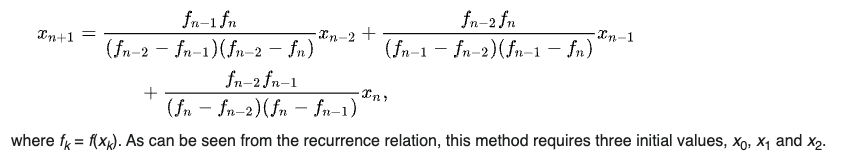

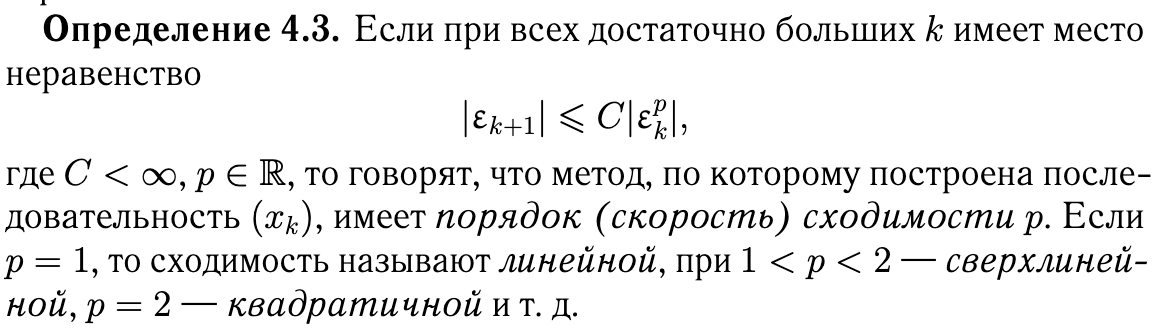

![теорема-2.3.png](./photos/теорема-2.3.png)

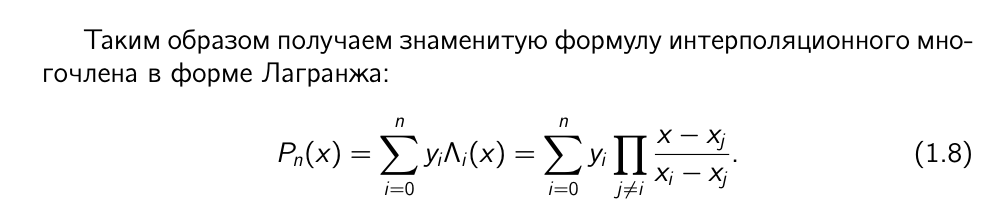

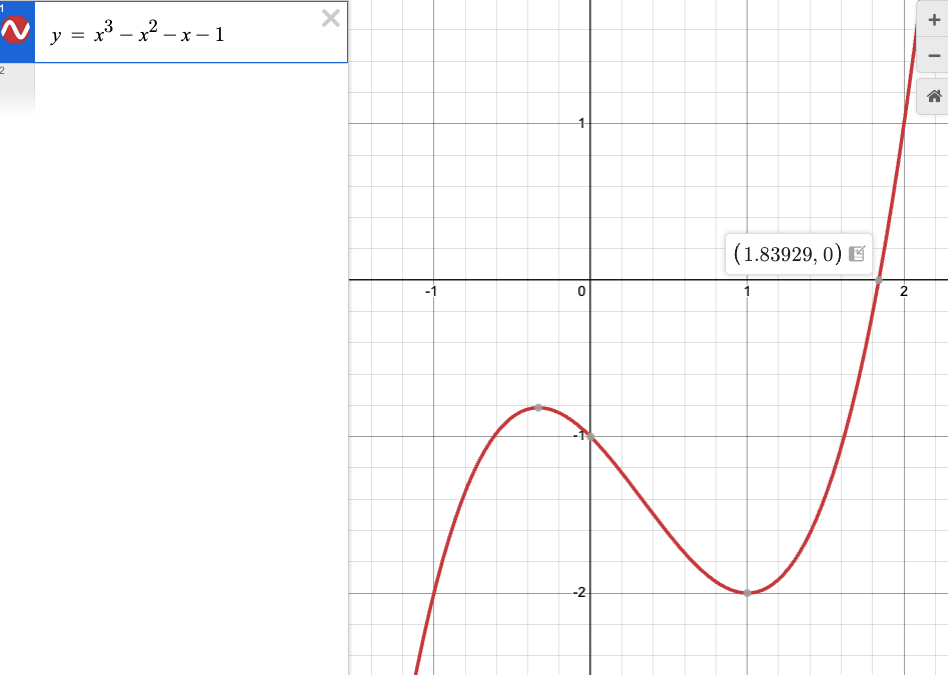

# Вычисление порядка сходимости

![д-1.jpg](./photos/д-1.jpg)

![д-2.jpg](./photos/д-2.jpg)

![д-3.jpg](./photos/д-3.jpg)

In [52]:
def inverse_quadratic_interpolation_method(
    f, # функция
    x0, x1, x2, # начальные приближения
    x_solution, # точное значение корня, чтобы считать ошибку 
    eps=1e-12, # точность
    max_iterations=20 # макс число итераций
):
    print("ОКИ")
    print(f"function: {f}")
    errors =[abs(x0 - x_solution), abs(x1 - x_solution), abs(x2 - x_solution)]  # для хранения погрешностей
    a, b, c = x0, x1, x2 # три текущие точки (x_k-2, x_k-1, x_k)
    
    for iteration in range(max_iterations):
        fa, fb, fc = f(a), f(b), f(c) # значения функций в точках
    
        if fa == fb or fa == fc or fb == fc: # чтобы в дальнейшем не поделить на 0
            break
            
        # применяем формулу
        term1 = (fb * fc) / ((fa - fb) * (fa - fc)) * a
        term2 = (fa * fc) / ((fb - fa) * (fb - fc)) * b
        term3 = (fa * fb) / ((fc - fa) * (fc - fb)) * c
        x_new = term1 + term2 + term3
        
        errors.append(abs(x_new - x_solution)) # добавляем ошибку
        if abs(f(x_new)) < eps: # f(x_k+1) < eps
            break
        a, b, c = b, c, x_new # x_k-2, x_k-1, x_k -> x_k-1, x_k, x_k+1
        print(f"it: {iteration + 1} a: {a}, b: {b}, c: {c}")
    print()
    return errors

## `Вычисления и графики`

порядки сходимостей методов Ньютона и Секущей 2 и 1.618 соответственно ([исходя из](<../../теория/[20.09.2020] МВ конспект - 104-125.pdf>))

Ньютон
f: <function f1 at 0x123074d30>
it: 1, current_x: 1.5663110031972183
it: 2, current_x: 1.5671431650348622
it: 3, current_x: 1.567143290409781
it: 4, current_x: 1.567143290409784

Секущая
f: <function f1 at 0x123074d30>
it: 1, a: 1.0, b: 0.6126998367802821
it: 2, a: 0.6126998367802821, b: 0.5638383891610742
it: 3, a: 0.5638383891610742, b: 0.5671703584197446
it: 4, a: 0.5671703584197446, b: 0.5671433066049633

ОКИ
function: <function f1 at 0x123074d30>
it: 1 a: 1.0, b: 0.5, c: 0.5672721726782622
it: 2 a: 0.5, b: 0.5672721726782622, c: 0.5671432847571816

Ньютон
f: <function f2 at 0x12499ad40>
it: 1, current_x: 2.0503424020670993
it: 2, current_x: 2.1141812506271154
it: 3, current_x: 2.1141571408471975
it: 4, current_x: 2.11415714087193
it: 5, current_x: 2.1141571408719297

Секущая
f: <function f2 at 0x12499ad40>
it: 1, a: 1.4, b: 1.0744530330977753
it: 2, a: 1.0744530330977753, b: 1.1157809351651218
it: 3, a: 1.1157809351651218, b: 1.1141589452387664
it: 4, a: 1.1141589452387664,

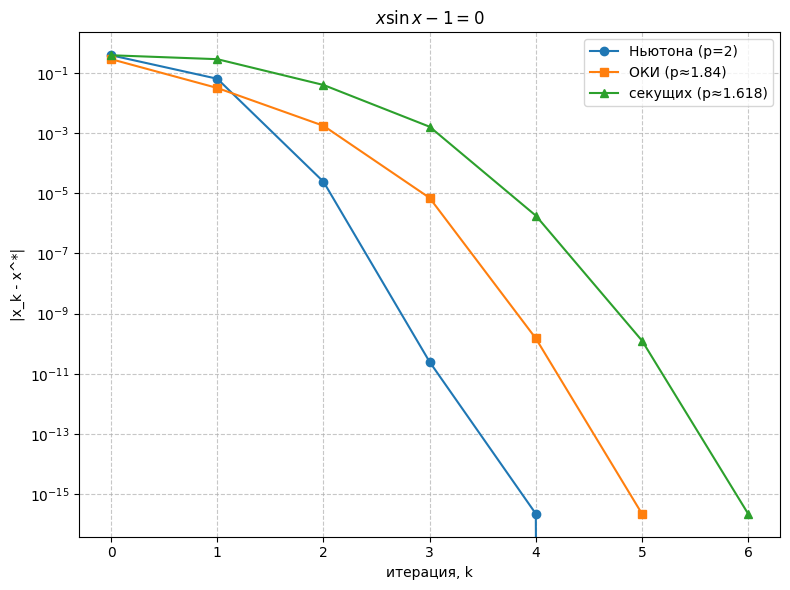

In [75]:
# уравнение 1
x_solution_1 = 0.5671432904097838
err_newton_1 = newton_method(f1, df1, 0.5, x_solution_1)
err_secant_1 = secant_method(f1, 0.0, 1.0, x_solution_1)
err_iqi_1    = inverse_quadratic_interpolation_method(f1, 0.0, 1.0, 0.5, x_solution_1)

# уравнение 2
x_solution_2 = 1.1141571408719300
err_newton_2 = newton_method(f2, df2, 1.5, x_solution_2)
err_secant_2 = secant_method(f2, 1.5, 1.4, x_solution_2)
err_iqi_2    = inverse_quadratic_interpolation_method(f2, 1.4, 1.1456745414688143, 1.1159043790663805, x_solution_2) # 1.0163475399040172, 1.1050056016809153, 1.1140348254936252

# функция для построения
def plot_convergence(err_newton, err_secant, err_iqi, title):
    plt.figure(figsize=(8, 6))
    plt.plot(range(len(err_newton)), err_newton, 'o-', label='Ньютона (p=2)')
    plt.plot(range(len(err_iqi)), err_iqi, 's-', label='ОКИ (p≈1.84)')
    plt.plot(range(len(err_secant)), err_secant, '^-', label='секущих (p≈1.618)')
    
    plt.yscale('log')
    plt.xlabel('итерация, k')
    plt.ylabel('|x_k - x^*|')
    plt.title(title)
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

# построение
# plot_convergence(err_newton_1, err_secant_1, err_iqi_1, '$e^{-x} - x = 0$')
plot_convergence(err_newton_2, err_secant_2, err_iqi_2, '$x \sin x - 1 = 0$')